In [1]:
# ----------------- 第一步：加载 CIFAR-10 数据集 -----------------

import torch
import torchvision
import torchvision.transforms as transforms

batch_size = 4
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 1. 数据规范化变换：ToTensor()将PIL图转成[0,1]的张量；Normalize将值域缩放到[-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 均值、标准差均为0.5
])

# 2. 加载训练集（自动下载到./data）
trainset = torchvision.datasets.CIFAR10(
    root='./data',      # 数据存储路径
    train=True,         # True=训练集
    download=True,      # 未下载则自动下载
    transform=transform # 应用上述变换
)
# 训练集DataLoader（shuffle=True打乱顺序，多线程num_workers加速）
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# 3. 加载测试集（无需打乱）
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,        # False=测试集
    download=True,
    transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,       # 测试集无需打乱
    num_workers=2
)

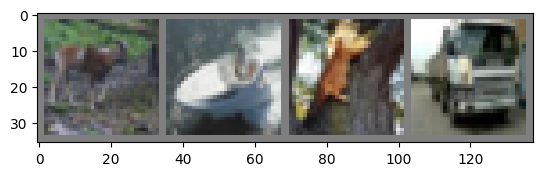

 deer  ship   cat truck


In [3]:
# 在完成数据加载后，可使用以下代码检查加载数据的正确性。

import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# 随机取一个批次的训练数据
dataiter = iter(trainloader)
images, labels = next(dataiter)
# 展示图像
imshow(torchvision.utils.make_grid(images))
# 打印相关图像的标签
print(' '.join('%5s' % classes[labels[j]] for j in range(batch_size)))

In [8]:
# ----------------- 第二步：定义 MyNet 卷积神经网络 -----------------

import torch.nn as nn
import torch.nn.functional as F

class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 卷积层+池化层
        self.conv1 = nn.Conv2d(3, 6, 5)       # 输入3→输出6，5×5卷积
        self.pool = nn.MaxPool2d(2, 2)        # 2×2池化（stride=2，尺寸减半）
        self.conv2 = nn.Conv2d(6, 16, 5)      # 6→16，5×5卷积

        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        # 前向传播：conv1→pool→conv2→pool→展平→fc1→fc2→fc3
        x = self.pool(F.relu(self.conv1(x)))  # conv1+ReLU+池化
        x = self.pool(F.relu(self.conv2(x)))  # conv2+ReLU+池化
        x = x.view(-1, 16*5*5)                # 展平（batch_size×(-1)，16通道×5×5尺寸）
        x = F.relu(self.fc1(x))               # fc1+ReLU
        x = F.relu(self.fc2(x))               # fc2+ReLU
        x = self.fc3(x)                       # fc3（输出logits，无激活）
        return x

In [9]:
# 定义完成后，可使用以下代码检查网络结构的正确性，打印输出应与前面所展示的网络结构一致。

mynet = MyNet()
print(mynet)

MyNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [10]:
# ----------------- 第三步：定义定义损失函数与优化器 -----------------

import torch.optim as optim

# 1. 交叉熵损失（适用于多分类，自动处理logits→概率）
criterion = nn.CrossEntropyLoss()

# 2. 带动量的SGD优化器（学习率0.001，动量0.9）
optimizer = optim.SGD(mynet.parameters(), lr=0.001, momentum=0.9)

In [11]:
# ----------------- 第四步：训练图像分类器 -----------------

from tqdm.notebook import tqdm
import torch

# 设备选择（先默认CPU，任务7再改GPU）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
mynet.to(device)  # 模型移到设备

n_epochs = 2
n_batches = 100  # 每n_batches个batch打印一次损失
pbar = tqdm(total=n_epochs)

for epoch in range(n_epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 1. 获取数据并移到设备，这里 data 是形如 [inputs, labels] 的列表
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 2. 梯度清零，防止错误的梯度累加
        optimizer.zero_grad()
        
        # 3. 前向传播
        outputs = mynet(inputs)
        
        # 4. 计算损失
        loss = criterion(outputs, labels)
        
        # 5. 反向传播+参数更新
        loss.backward()
        optimizer.step()
        
        # 6. 统计损失函数的滑动平均
        running_loss += loss.item()
        if (i+1) % n_batches == 0:
            pbar.set_postfix(batch=i+1, loss=running_loss/n_batches)
            running_loss = 0.0
    
    pbar.update()  # 更新epoch进度条

print('训练完成')
# 保存模型
torch.save(mynet.state_dict(), "cifar_net.pth")

  0%|          | 0/2 [00:00<?, ?it/s]

训练完成


In [12]:
# ----------------- 第五步：在测试集上评估模型性能 -----------------

mynet.load_state_dict(torch.load("cifar_net.pth"))  # 加载训练好的模型
mynet.eval()  # 切换到评估模式（关闭Dropout等）

correct = 0
total = 0

with torch.no_grad():  # 评估时无需计算梯度（节省内存+加速）
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        # 前向传播得输出
        outputs = mynet(images)
        
        # 取概率最大的类别作为预测（torch.max返回最大值和索引）
        _, predicted = torch.max(outputs.data, 1)  # 1表示按行取最大值（每个样本的10类中选最大的）
        
        # 统计总数与正确数
        total += labels.size(0)  # 每个batch的样本数
        correct += (predicted == labels).sum().item()  # 正确预测的数量

print('网络在测试集上的准确率是: %3.1f %%' % (100 * correct / total))

网络在测试集上的准确率是: 55.0 %


In [13]:
# ----------------- 改进一：统计各类别测试样本准确率 ----------------

# 目标：计算每个类别的单独准确率（而非整体）
# ·为每个类别维护正确预测数和该类总样本数；
# ·遍历测试集时，对每个样本：若预测正确，则对应类别的正确数+1；同时该类总样本数+1；
# ·最后计算每个类别的准确率（正确数/总样本数×100%）。

class_correct = list(0. for i in range(10))  # 10类，每类的正确数
class_total = list(0. for i in range(10))    # 每类的总样本数

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = mynet(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()  # 压缩维度（batch_size→1维）
        
        # 遍历每个样本
        for i in range(batch_size):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# 打印每类准确率
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 72 %
Accuracy of   car : 70 %
Accuracy of  bird : 37 %
Accuracy of   cat : 15 %
Accuracy of  deer : 47 %
Accuracy of   dog : 47 %
Accuracy of  frog : 60 %
Accuracy of horse : 67 %
Accuracy of  ship : 66 %
Accuracy of truck : 65 %


In [15]:
# ----------------- 改进二：改进图像分类模型 ----------------
# 为更加清晰地对比，我们将原特征通道模型保留与改进后的中等通道、更大通道模型一同输出结果

import torch.nn as nn
import torch.nn.functional as F

# ========== 原始版本（对照） ==========
class MyNet_base(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)      # 3→6
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)     # 6→16
        # 计算全连接输入：16 * 5 * 5 = 400
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ========== 改进版本 1：中等通道数 ==========
class MyNet_medium(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 5)     # 3→32
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5)    # 32→64
        # 计算全连接输入：64 * 5 * 5 = 1600
        self.fc1 = nn.Linear(1600, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ========== 改进版本 2：更大通道数 ==========
class MyNet_large(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 5)     # 3→64
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, 5)   # 64→128
        # 计算全连接输入：128 * 5 * 5 = 3200
        self.fc1 = nn.Linear(3200, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 128 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [16]:
# 为方便比较，我们使用一个通用的训练和评估函数

import torch
import torch.optim as optim
from tqdm.notebook import tqdm

def train_and_eval(model, trainloader, testloader, epochs=2, lr=0.001, momentum=0.9, device='cpu'):
    # 定义损失函数与优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    
    model.to(device)
    model.train()
    
    n_batches = 100
    pbar = tqdm(total=epochs)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if (i + 1) % n_batches == 0:
                pbar.set_postfix(batch=i+1, loss=running_loss/n_batches)
                running_loss = 0.0
        pbar.update()
    pbar.close()
    print('训练完成')
    
    # 保存模型
    model_path = f"{model.__class__.__name__}.pth"
    torch.save(model.state_dict(), model_path)
    
    # 评估
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'{model.__class__.__name__} 在测试集上的准确率: {accuracy:.1f}%')
    return accuracy

In [17]:
# 最后我们对不同的模型进行对比

# 实例化不同模型
models = {
    "MyNet_base": MyNet_base(),
    "MyNet_medium": MyNet_medium(), 
    "MyNet_large": MyNet_large()
}

# 训练和评估每个模型
results = {}
for name, model in models.items():
    print(f"\n===== 开始训练 {name} =====")
    acc = train_and_eval(model, trainloader, testloader, epochs=2, device=device)
    results[name] = acc


===== 开始训练 MyNet_base =====


  0%|          | 0/2 [00:00<?, ?it/s]

训练完成
MyNet_base 在测试集上的准确率: 54.5%

===== 开始训练 MyNet_medium =====


  0%|          | 0/2 [00:00<?, ?it/s]

训练完成
MyNet_medium 在测试集上的准确率: 62.6%

===== 开始训练 MyNet_large =====


  0%|          | 0/2 [00:00<?, ?it/s]

训练完成
MyNet_large 在测试集上的准确率: 67.9%
